<a href="https://colab.research.google.com/github/Sri939/Srikanth-assignment1/blob/main/srikanth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [ ]:
import zipfile

zip_ref = zipfile.ZipFile('archive (2).zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
import os
os.listdir('/content')

['.config', 'archive (2).zip', 'retail_store_inventory.csv', 'sample_data']

In [ ]:
import pandas as pd

data = pd.read_csv('retail_store_inventory.csv')
data.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [ ]:
data.info()
data.describe()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

,0
Date,0
Store ID,0
Product ID,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Demand Forecast,0
Price,0


In [ ]:
data = data.dropna()

In [ ]:
data['Date'] = pd.to_datetime(data['Date'])

In [ ]:
print(data.columns)

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality'],
      dtype='object')


In [ ]:
import pandas as pd

# convert Date column to datetime
data['Date'] = pd.to_datetime(data['Date'])

# check result
print(data.head())

        Date Store ID Product ID     Category Region  Inventory Level  \
0 2022-01-01     S001      P0001    Groceries  North              231   
1 2022-01-01     S001      P0002         Toys  South              204   
2 2022-01-01     S001      P0003         Toys   West              102   
3 2022-01-01     S001      P0004         Toys  North              469   
4 2022-01-01     S001      P0005  Electronics   East              166   

   Units Sold  Units Ordered  Demand Forecast  Price  Discount  \
0         127             55           135.47  33.50        20   
1         150             66           144.04  63.01        20   
2          65             51            74.02  27.99        10   
3          61            164            62.18  32.72        10   
4          14            135             9.26  73.64         0   

  Weather Condition  Holiday/Promotion  Competitor Pricing Seasonality  
0             Rainy                  0               29.69      Autumn  
1             Sunn

In [ ]:
 import numpy as np

data['Sales'] = np.random.randint(100, 1000, size=len(data))

In [ ]:
monthly_sales = data.groupby(data['Date'].dt.month)['Sales'].sum()
print(monthly_sales)

Date
1     3467355
2     3056526
3     3396660
4     3304968
5     3425819
6     3318305
7     3409244
8     3418028
9     3311090
10    3372991
11    3252422
12    3402718
Name: Sales, dtype: int64


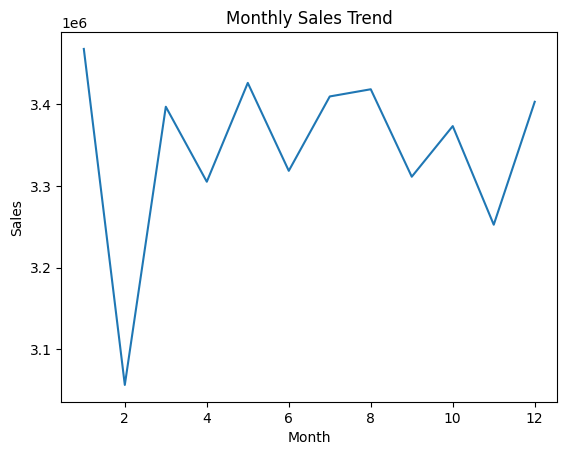

In [ ]:
monthly_sales.plot(kind='line')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

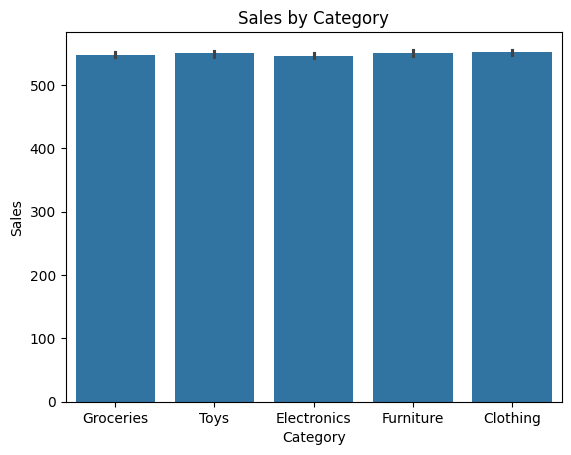

In [ ]:
sns.barplot(x='Category', y='Sales',data=data)

plt.title("Sales by Category")

plt.show()

In [ ]:
sales = data.groupby('Date')['Sales'].sum()

In [ ]:
from sklearn.linear_model import LinearRegression

sales = sales.reset_index()

sales['Day'] = range(len(sales))

X = sales[['Day']]
y = sales['Sales']

model = LinearRegression()
model.fit(X, y)

future_days = np.array(range(len(sales), len(sales)+30)).reshape(-1,1)

future_sales = model.predict(future_days)

print(future_sales)

[54680.73642786 54680.12155165 54679.50667544 54678.89179922
 54678.27692301 54677.6620468  54677.04717059 54676.43229437
 54675.81741816 54675.20254195 54674.58766573 54673.97278952
 54673.35791331 54672.7430371  54672.12816088 54671.51328467
 54670.89840846 54670.28353224 54669.66865603 54669.05377982
 54668.43890361 54667.82402739 54667.20915118 54666.59427497
 54665.97939875 54665.36452254 54664.74964633 54664.13477012
 54663.5198939  54662.90501769]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


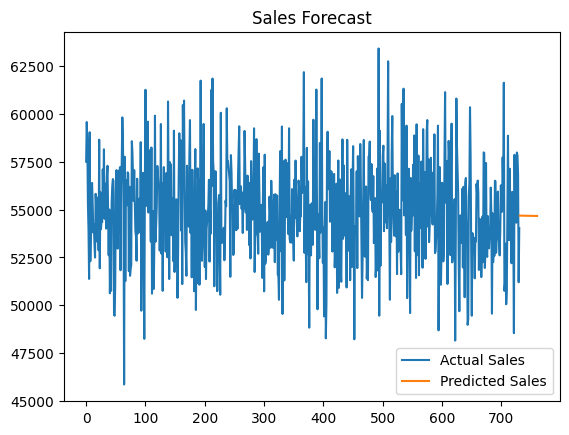

In [ ]:
plt.plot(sales['Day'], sales['Sales'], label='Actual Sales')

plt.plot(future_days, future_sales, label='Predicted Sales')

plt.legend()

plt.title("Sales Forecast")

plt.show()